In [9]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
.inner_cell{font-size:20pt;}
div.text_cell_render pre code {font-size:20pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

# 1. 데이터 생성
- 남여 키와 몸무게 데이터를 군집화

In [10]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [11]:
random.randint(140, 170)

152

In [12]:
random.randint(160, 195)

183

In [13]:
data = []
for i in range(50):
    #print(i)
    #여자데이터(몸무게와 키) 추가
    data.append([random.randint(40,70), random.randint(140,170)])
    #남자데이터(몸무게와 키) 추가
    data.append([random.randint(60,95), random.randint(160,195)])

In [14]:
print('여자몸무게(x축) :',[female[0] for female in data[::2]])
print('여자키(y축) :',[female[1] for female in data[::2]])

print('남자몸무게(x축) :',[male[0] for male in data[1::2]])
print('남자키(y축) :',[male[1] for male in data[1::2]])

여자몸무게(x축) : [52, 63, 50, 51, 43, 59, 61, 69, 60, 57, 66, 70, 41, 40, 58, 40, 62, 60, 52, 51, 65, 60, 69, 53, 64, 51, 53, 43, 49, 53, 54, 50, 43, 58, 69, 64, 58, 54, 63, 69, 67, 58, 50, 41, 61, 41, 59, 69, 42, 70]
여자키(y축) : [150, 170, 167, 146, 142, 170, 141, 158, 156, 142, 150, 143, 164, 155, 162, 155, 153, 153, 150, 155, 164, 159, 153, 157, 170, 147, 154, 148, 142, 164, 165, 155, 155, 164, 160, 148, 163, 147, 155, 170, 160, 165, 153, 145, 163, 156, 158, 151, 160, 157]
남자몸무게(x축) : [75, 88, 90, 72, 79, 93, 63, 68, 72, 60, 62, 91, 95, 77, 66, 64, 81, 70, 82, 77, 64, 86, 93, 91, 92, 66, 88, 72, 82, 67, 94, 81, 66, 62, 84, 94, 87, 70, 90, 64, 83, 65, 75, 78, 95, 90, 83, 67, 74, 86]
남자키(y축) : [187, 184, 179, 173, 170, 168, 165, 194, 160, 176, 191, 185, 171, 183, 183, 179, 180, 183, 165, 161, 180, 161, 194, 174, 175, 161, 188, 194, 184, 181, 173, 170, 170, 183, 185, 180, 163, 163, 176, 192, 188, 174, 163, 185, 194, 171, 175, 181, 171, 172]


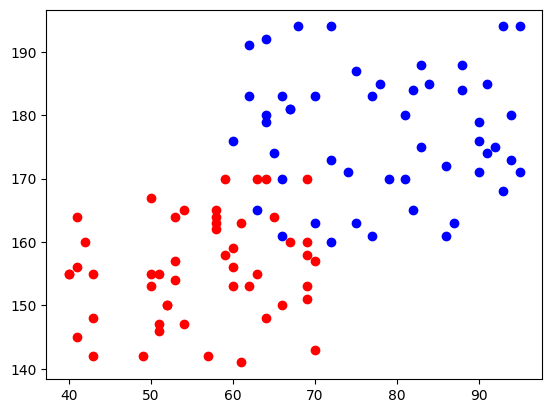

In [15]:
plt.plot([female[0] for female in data[::2]],
        [female[1] for female in data[::2]],'o', color='r')
plt.plot([male[0] for male in data[1::2]],
        [male[1] for male in data[1::2]],'o', color='b')
plt.show()

# 2. 군집화 로직

In [17]:
#초기 랜덤 지점 2개
random_points = [
    [random.randint(40,90),random.randint(140,195)],
    [random.randint(40,90),random.randint(140,195)]
]
random_points[0],random_points[1]

[[42, 158], [75, 174]]

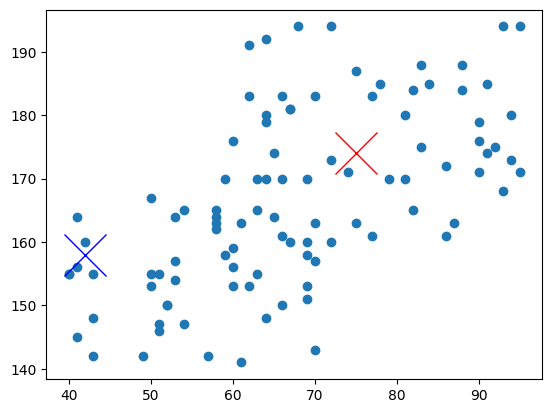

In [29]:
plt.plot([d[0] for d in data],[d[1] for d in data],'o')
plt.plot(random_points[0][0],random_points[0][1],'x',markersize=30,color='b') # 기준점0
plt.plot(random_points[1][0],random_points[1][1],'x',markersize=30,color='r') # 기준점1

In [24]:
# 두점 거리를 return하는 함수 점은 [0,0]
def dist(a,b):
    return np.sqrt((a[0]-b[0])**2+(a[1]-b[1])**2)
print(dist([3,4],[0,0]))

5.0


In [30]:
#random_points[0]에 가까운 그룹(group0)과 random_points[1]에 가까운 그룹(group1)을 분류
group0=[]
group1=[]
for d in data:
    if dist(random_points[0],d) < dist(random_points[1],d):
        group0.append(d)
    else:
        group1.append(d)
len(group0), len(group1)
        


(37, 63)

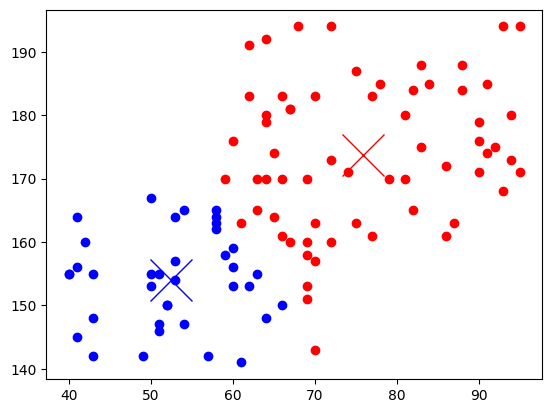

In [43]:
#group0과 group1, random_points[0]과 random_points[1]
plt.plot([d[0] for d in group0], [d[1] for d in group0],'o', color='b')
plt.plot([d[0] for d in group1], [d[1] for d in group1],'o', color='r')
plt.plot(random_points[0][0], random_points[0][1], 'x', markersize=30, color='b')
plt.plot(random_points[1][0], random_points[1][1], 'x', markersize=30, color='r')

In [41]:
#기준점을 이동 group0과 group1 중심점으로 기준점을 이동
group0_meanX=np.mean([d[0] for d in group0])
group0_meanY=np.mean([d[1] for d in group0])
random_points[0] = [group0_meanX,group0_meanY]
random_points[0]

[52.45945945945946, 154.0810810810811]

In [42]:
group1_meanX=np.mean([d[0] for d in group1])
group1_meanY=np.mean([d[1] for d in group1])
random_points[1] = [group1_meanX,group1_meanY]
random_points[1]

[75.84126984126983, 173.76190476190476]

In [44]:
random_points

[[52.45945945945946, 154.0810810810811],
 [75.84126984126983, 173.76190476190476]]